# 動的LCA計算結果の可視化とCRF/DCFシミュレーション

Levasseur型のCRF・DCFの関係、RE2020近似、木材の炭素固定・将来放出ケース、Bernモデルパラメータ感度を可視化します。

## 1. 準備

ブラウザ上のJupyterでもプロジェクト内の `src` を参照できるようにし、日本語文字化け対策として `japanize_matplotlib` を読み込みます。

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt
import japanize_matplotlib
import ipywidgets as widgets
from IPython.display import Markdown, display

from dynamic_lca import BernModel, Flow, crf_co2, dcf_co2, dcf_re2020, dynamic_gwp, impulse_response_co2, static_gwp

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (9, 5)

print("日本語フォント設定が有効です。")
print("dynamic_lca import OK")

日本語フォント設定が有効です。
dynamic_lca import OK


## 2. CRF関数とDCF関数の関係

DCFは `DCF(t, HTI) = CRF(t, HTI) / CRF(0, HTI)` です。分母の `CRF(0, HTI)` は評価期間 `[0, HTI]` 全体を積分する固定基準であり、分子の `CRF(t, HTI)` は発生年 `t` から評価期間末まで、経過時間で表すと `[0, HTI - t]` だけを積分する可変値です。

下の図では、青い面積を分母、オレンジの面積を分子として表示します。`t` が大きくなるほどオレンジの積分範囲が短くなり、DCFが小さくなります。

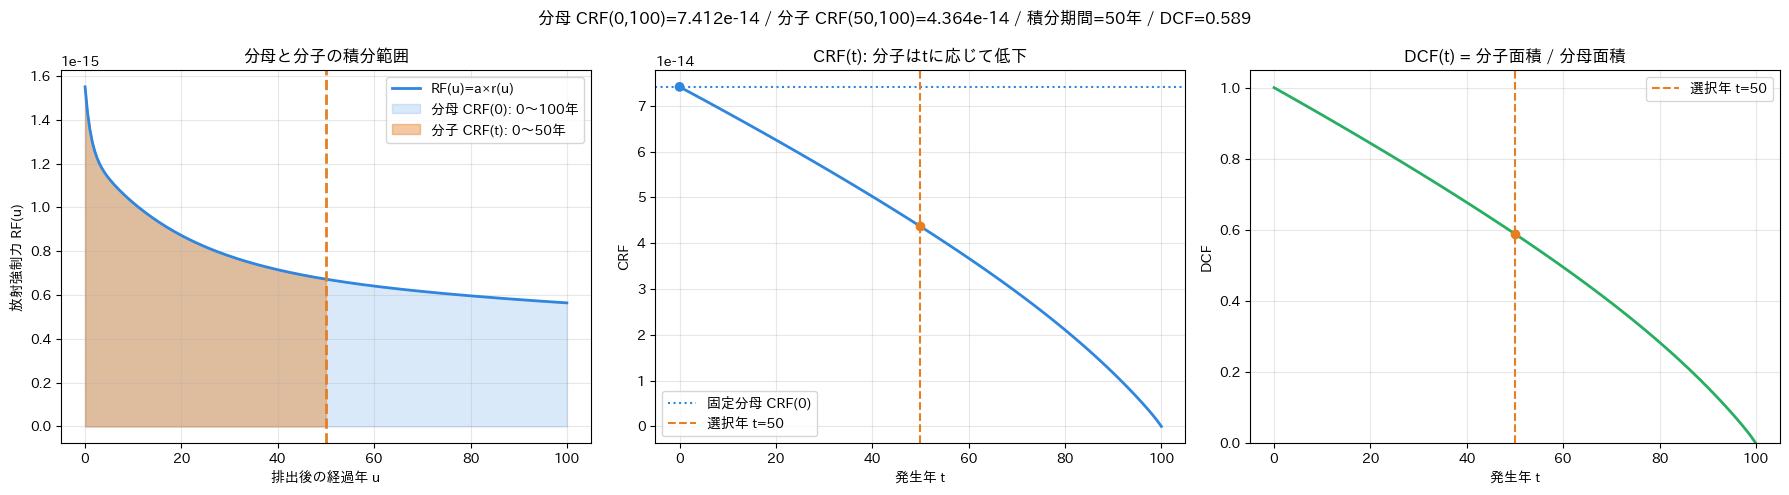


**CRF/DCFの読み方**

- **分母**: `CRF(0, 100) = ∫[0, 100] RF(u) du = 7.412061e-14`
- **分子**: `CRF(50, 100) = ∫[0, 50] RF(u) du = 4.364235e-14`
- **DCF**: `CRF(50, 100) / CRF(0, 100) = 0.588802`
- **意味**: 発生年 `t` が遅くなるほど、分子の積分範囲 `HTI - t` が短くなり、DCFが小さくなります。


In [ ]:
def _rf_curve_values(duration, step_years, model):
    count = int(duration / step_years) + 1
    xs = [min(i * step_years, duration) for i in range(count + 1)]
    ys = [model.radiative_efficiency * impulse_response_co2(x, model=model) for x in xs]
    return xs, ys


def plot_crf_dcf_relationship(t=50, hti=100, step_years=0.5):
    t = min(t, hti)
    reference_crf = crf_co2(0, horizon_years=hti, step_years=step_years)
    selected_crf = crf_co2(t, horizon_years=hti, step_years=step_years)
    selected_dcf = dcf_co2(t, horizon_years=hti, step_years=step_years)
    numerator_duration = hti - t

    elapsed_years, rf_values = _rf_curve_values(hti, step_years, BernModel())
    numerator_x = [x for x in elapsed_years if x <= numerator_duration]
    numerator_y = rf_values[: len(numerator_x)]
    occurrence_years = list(range(0, int(hti) + 1))
    crf_values = [crf_co2(year, horizon_years=hti, step_years=step_years) for year in occurrence_years]
    dcf_values = [dcf_co2(year, horizon_years=hti, step_years=step_years) for year in occurrence_years]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(elapsed_years, rf_values, color="#2e86de", linewidth=2, label="RF(u)=a×r(u)")
    axes[0].fill_between(elapsed_years, rf_values, color="#2e86de", alpha=0.18, label=f"分母 CRF(0): 0〜{hti}年")
    axes[0].fill_between(numerator_x, numerator_y, color="#e67e22", alpha=0.42, label=f"分子 CRF(t): 0〜{numerator_duration}年")
    axes[0].axvline(numerator_duration, color="#e67e22", linestyle="--", linewidth=2)
    axes[0].set_title("分母と分子の積分範囲")
    axes[0].set_xlabel("排出後の経過年 u")
    axes[0].set_ylabel("放射強制力 RF(u)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(occurrence_years, crf_values, color="#2e86de", linewidth=2)
    axes[1].fill_between(occurrence_years, crf_values, color="#2e86de", alpha=0.16)
    axes[1].axhline(reference_crf, color="#2e86de", linestyle=":", label="固定分母 CRF(0)")
    axes[1].axvline(t, color="#e67e22", linestyle="--", label=f"選択年 t={t}")
    axes[1].scatter([0, t], [reference_crf, selected_crf], color=["#2e86de", "#e67e22"], zorder=3)
    axes[1].set_title("CRF(t): 分子はtに応じて低下")
    axes[1].set_xlabel("発生年 t")
    axes[1].set_ylabel("CRF")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(occurrence_years, dcf_values, color="#27ae60", linewidth=2)
    axes[2].fill_between(occurrence_years, dcf_values, color="#27ae60", alpha=0.16)
    axes[2].axvline(t, color="#e67e22", linestyle="--", label=f"選択年 t={t}")
    axes[2].scatter([t], [selected_dcf], color="#e67e22", zorder=3)
    axes[2].set_title("DCF(t) = 分子面積 / 分母面積")
    axes[2].set_xlabel("発生年 t")
    axes[2].set_ylabel("DCF")
    axes[2].set_ylim(0, 1.05)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    fig.suptitle(
        f"分母 CRF(0,{hti})={reference_crf:.3e} / 分子 CRF({t},{hti})={selected_crf:.3e} / "
        f"積分期間={numerator_duration}年 / DCF={selected_dcf:.3f}"
    )
    plt.tight_layout()
    plt.show()

    display(Markdown(f"""
**CRF/DCFの読み方**

- **分母**: `CRF(0, {hti}) = ∫[0, {hti}] RF(u) du = {reference_crf:.6e}`
- **分子**: `CRF({t}, {hti}) = ∫[0, {numerator_duration}] RF(u) du = {selected_crf:.6e}`
- **DCF**: `CRF({t}, {hti}) / CRF(0, {hti}) = {selected_dcf:.6f}`
- **意味**: 発生年 `t` が遅くなるほど、分子の積分範囲 `HTI - t` が短くなり、DCFが小さくなります。
"""))

plot_crf_dcf_relationship()

## 3. CRF/DCF関係のインタラクティブ表示

`t`、`HTI`、数値積分刻みをスライダーで変更し、CRFとDCFの関係がどう変わるかを確認します。

## 4. Bernモデルパラメータ感度と木材GWPの前提別比較

Bernモデルの係数と時定数を変更し、インパルス応答、CRF、DCF、木材ケースの動的GWPへの影響を確認します。

木材ケースでは、`-1/+1` アプローチのもとで `-100 kgCO2` の固定と `+100 kgCO2` の将来放出を同時に扱います。静的GWPでは時間を区別しないため `-100 + 100 = 0` になります。一方、動的GWPでは固定は `DCF(0)=1`、将来放出は `DCF(DO)<1` で重み付けされるため、完全には相殺されません。

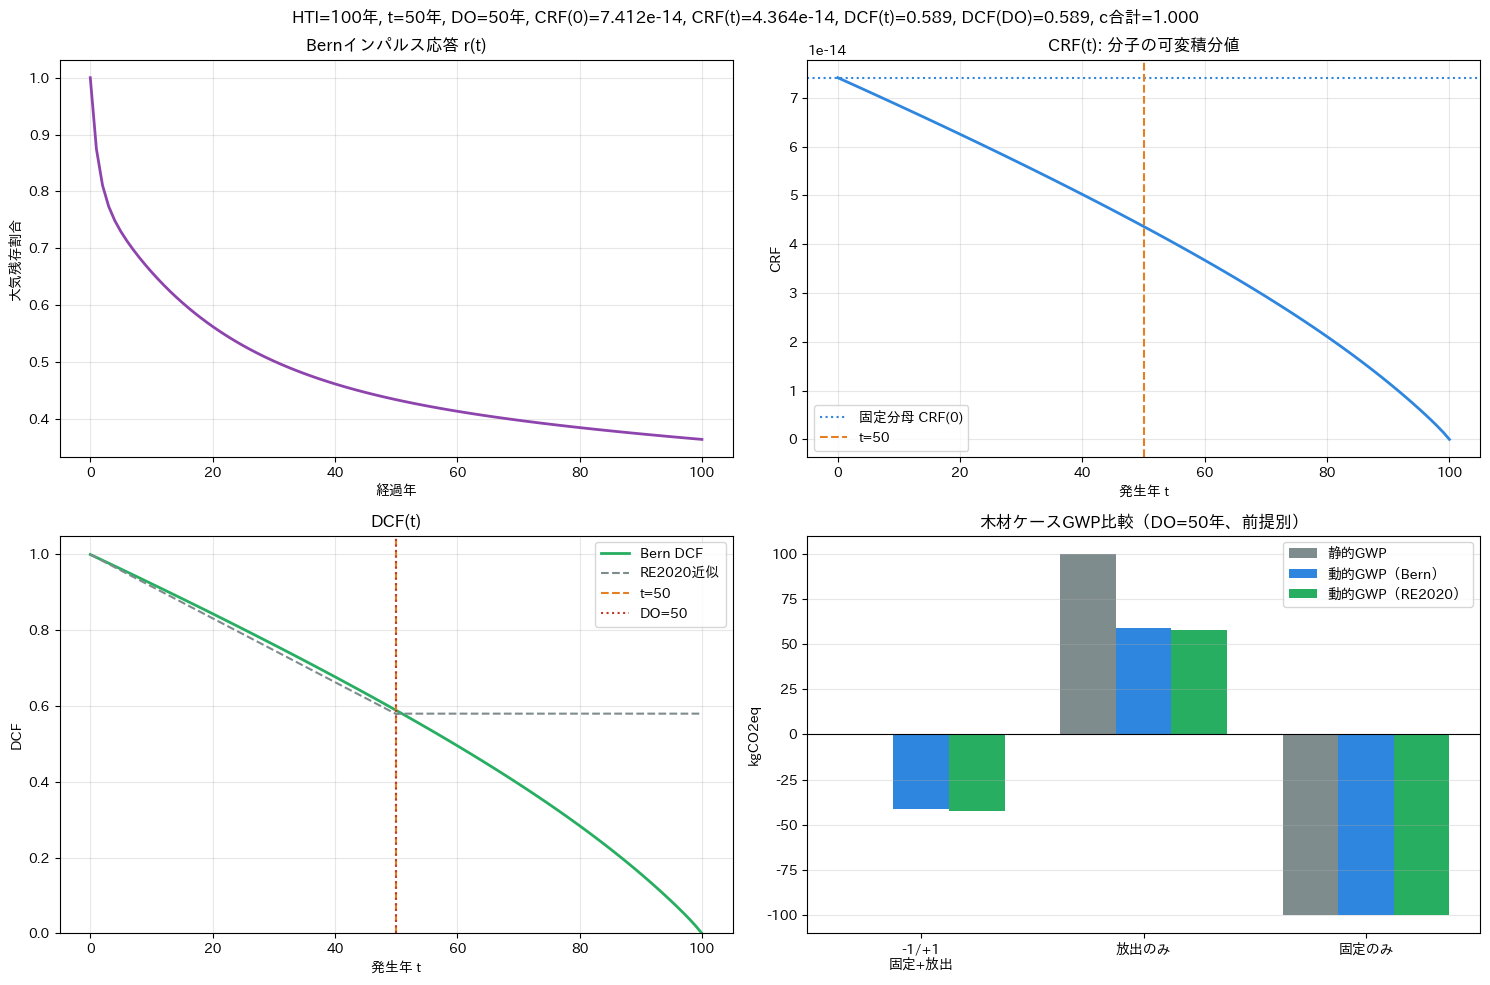


**計算値の要約**

- **CRF(0)**: `7.412061e-14`
- **CRF(50)**: `4.364235e-14`
- **DCF(50) = CRF(50) / CRF(0)**: `0.588802`
- **c0+c1+c2+c3**: `1.000`

**なぜ静的GWPが0になるか**

- **前提**: `-1/+1` アプローチでは、製造時の炭素固定 `-100 kgCO2` と使用後の放出 `+100 kgCO2` を両方計上します。
- **静的GWP**: `(-100×1) + (100×1) = 0.000 kgCO2eq`
- **動的GWP（Bern）**: `(-100×DCF(0)) + (100×DCF(50)) = -100×1 + 100×0.588802 = -41.120 kgCO2eq`
- **解釈**: 静的LCAは時間を区別しないため等量なら相殺されます。動的LCAは将来放出を `DCF(DO)<1` で重み付けするため、固定と放出が完全には相殺されません。

**-1/+1ケースのフロー別寄与**

`[{'区分': 'A1-A3', '名称': 'バイオジェニック炭素固定', '発生年': 0, '量 kgCO2': -100, '静的寄与': -100.0, 'DCF Bern': 1.0, '動的寄与 Bern': -100.0, 'DCF RE2020': 1.0, '動的寄与 RE2020': -100.0}, {'区分': 'C', '名称': '使用後の炭素放出', '発生年': 50, '量 kgCO2': 100, '静的寄与': 100.0, 'DCF Bern': 0.588802, '動的寄与 Bern': 58.88, 'DCF RE2020': 0.579, '動的寄与 RE2020': 57.9}]`


In [ ]:
def _wood_case_scenarios(do):
    return {
        "-1/+1\n固定+放出": [
            Flow(year=0, amount=-100, name="バイオジェニック炭素固定", category="A1-A3"),
            Flow(year=do, amount=100, name="使用後の炭素放出", category="C"),
        ],
        "放出のみ": [
            Flow(year=do, amount=100, name="使用後の炭素放出", category="C"),
        ],
        "固定のみ": [
            Flow(year=0, amount=-100, name="バイオジェニック炭素固定", category="A1-A3"),
        ],
    }


def _flow_contribution_rows(flows, hti, step_years, model):
    rows = []
    for flow in flows:
        bern_dcf = dcf_co2(flow.year, horizon_years=hti, step_years=step_years, model=model)
        re2020_dcf = dcf_re2020(flow.year)
        rows.append(
            {
                "区分": flow.category,
                "名称": flow.name,
                "発生年": flow.year,
                "量 kgCO2": flow.amount,
                "静的寄与": round(flow.amount * flow.gwp, 3),
                "DCF Bern": round(bern_dcf, 6),
                "動的寄与 Bern": round(flow.amount * flow.gwp * bern_dcf, 3),
                "DCF RE2020": round(re2020_dcf, 6),
                "動的寄与 RE2020": round(flow.amount * flow.gwp * re2020_dcf, 3),
            }
        )
    return rows


def simulate_bern_sensitivity(
    t=50,
    do=50,
    hti=100,
    step_years=0.5,
    c0=0.217,
    c1=0.259,
    c2=0.338,
    c3=0.186,
    tau1=172.9,
    tau2=18.51,
    tau3=1.186,
    radiative_efficiency=1.55e-15,
):
    model = BernModel(
        c0=c0,
        c1=c1,
        c2=c2,
        c3=c3,
        tau1=tau1,
        tau2=tau2,
        tau3=tau3,
        radiative_efficiency=radiative_efficiency,
    )
    years = list(range(0, int(hti) + 1))
    response_values = [impulse_response_co2(year, model=model) for year in years]
    crf_values = [crf_co2(year, horizon_years=hti, step_years=step_years, model=model) for year in years]
    dcf_values = [dcf_co2(year, horizon_years=hti, step_years=step_years, model=model) for year in years]

    scenarios = _wood_case_scenarios(do)
    scenario_results = {
        name: {
            "静的GWP": static_gwp(flows),
            "動的GWP（Bern）": dynamic_gwp(flows, method="bern", horizon_years=hti, step_years=step_years, model=model),
            "動的GWP（RE2020）": dynamic_gwp(flows, method="re2020"),
        }
        for name, flows in scenarios.items()
    }
    base_flows = scenarios["-1/+1\n固定+放出"]
    base_results = scenario_results["-1/+1\n固定+放出"]
    contribution_rows = _flow_contribution_rows(base_flows, hti, step_years, model)

    selected_crf = crf_co2(t, horizon_years=hti, step_years=step_years, model=model)
    reference_crf = crf_co2(0, horizon_years=hti, step_years=step_years, model=model)
    selected_dcf = dcf_co2(t, horizon_years=hti, step_years=step_years, model=model)
    do_dcf = dcf_co2(do, horizon_years=hti, step_years=step_years, model=model)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes[0, 0].plot(years, response_values, color="#8e44ad", linewidth=2)
    axes[0, 0].fill_between(years, response_values, color="#8e44ad", alpha=0.16)
    axes[0, 0].set_title("Bernインパルス応答 r(t)")
    axes[0, 0].set_xlabel("経過年")
    axes[0, 0].set_ylabel("大気残存割合")
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(years, crf_values, color="#2e86de", linewidth=2)
    axes[0, 1].fill_between(years, crf_values, color="#2e86de", alpha=0.16)
    axes[0, 1].axhline(reference_crf, color="#2e86de", linestyle=":", label="固定分母 CRF(0)")
    axes[0, 1].axvline(t, color="#e67e22", linestyle="--", label=f"t={t}")
    axes[0, 1].set_title("CRF(t): 分子の可変積分値")
    axes[0, 1].set_xlabel("発生年 t")
    axes[0, 1].set_ylabel("CRF")
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    axes[1, 0].plot(years, dcf_values, color="#27ae60", linewidth=2, label="Bern DCF")
    axes[1, 0].fill_between(years, dcf_values, color="#27ae60", alpha=0.16)
    axes[1, 0].plot(years, [dcf_re2020(year) for year in years], color="#7f8c8d", linestyle="--", label="RE2020近似")
    axes[1, 0].axvline(t, color="#e67e22", linestyle="--", label=f"t={t}")
    axes[1, 0].axvline(do, color="#c0392b", linestyle=":", label=f"DO={do}")
    axes[1, 0].set_title("DCF(t)")
    axes[1, 0].set_xlabel("発生年 t")
    axes[1, 0].set_ylabel("DCF")
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    x_labels = list(scenario_results.keys())
    x_positions = range(len(x_labels))
    width = 0.25
    static_values = [scenario_results[name]["静的GWP"] for name in x_labels]
    bern_values = [scenario_results[name]["動的GWP（Bern）"] for name in x_labels]
    re2020_values = [scenario_results[name]["動的GWP（RE2020）"] for name in x_labels]
    axes[1, 1].bar([x - width for x in x_positions], static_values, width=width, label="静的GWP", color="#7f8c8d")
    axes[1, 1].bar(x_positions, bern_values, width=width, label="動的GWP（Bern）", color="#2e86de")
    axes[1, 1].bar([x + width for x in x_positions], re2020_values, width=width, label="動的GWP（RE2020）", color="#27ae60")
    axes[1, 1].axhline(0, color="black", linewidth=0.8)
    axes[1, 1].set_title(f"木材ケースGWP比較（DO={do}年、前提別）")
    axes[1, 1].set_ylabel("kgCO2eq")
    axes[1, 1].set_xticks(list(x_positions))
    axes[1, 1].set_xticklabels(x_labels)
    axes[1, 1].grid(True, axis="y", alpha=0.3)
    axes[1, 1].legend()

    coefficient_sum = c0 + c1 + c2 + c3
    fig.suptitle(
        f"HTI={hti}年, t={t}年, DO={do}年, CRF(0)={reference_crf:.3e}, "
        f"CRF(t)={selected_crf:.3e}, DCF(t)={selected_dcf:.3f}, DCF(DO)={do_dcf:.3f}, c合計={coefficient_sum:.3f}"
    )
    plt.tight_layout()
    plt.show()

    static_formula = " + ".join([f"({flow.amount:.0f}×{flow.gwp:.0f})" for flow in base_flows])
    dynamic_formula = f"(-100×DCF(0)) + (100×DCF({do})) = -100×1 + 100×{do_dcf:.6f}"
    display(Markdown(f"""
**計算値の要約**

- **CRF(0)**: `{reference_crf:.6e}`
- **CRF({t})**: `{selected_crf:.6e}`
- **DCF({t}) = CRF({t}) / CRF(0)**: `{selected_dcf:.6f}`
- **c0+c1+c2+c3**: `{coefficient_sum:.3f}`

**なぜ静的GWPが0になるか**

- **前提**: `-1/+1` アプローチでは、製造時の炭素固定 `-100 kgCO2` と使用後の放出 `+100 kgCO2` を両方計上します。
- **静的GWP**: `{static_formula} = {base_results['静的GWP']:.3f} kgCO2eq`
- **動的GWP（Bern）**: `{dynamic_formula} = {base_results['動的GWP（Bern）']:.3f} kgCO2eq`
- **解釈**: 静的LCAは時間を区別しないため等量なら相殺されます。動的LCAは将来放出を `DCF(DO)<1` で重み付けするため、固定と放出が完全には相殺されません。

**-1/+1ケースのフロー別寄与**

`{contribution_rows}`
"""))

simulate_bern_sensitivity()

## 5. スライダーによる動的シミュレーション

時間パラメータとBernモデルパラメータを変更すると、インパルス応答、CRF、DCF、GWP比較が再計算されます。

In [5]:
widgets.interact(
    plot_crf_dcf_relationship,
    t=widgets.IntSlider(value=50, min=0, max=100, step=1, description="t"),
    hti=widgets.IntSlider(value=100, min=20, max=200, step=5, description="HTI"),
    step_years=widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description="積分刻み"),
);

interactive(children=(IntSlider(value=50, description='t'), IntSlider(value=100, description='HTI', max=200, m…

In [6]:
widgets.interact(
    simulate_bern_sensitivity,
    t=widgets.IntSlider(value=50, min=0, max=100, step=1, description="t"),
    do=widgets.IntSlider(value=50, min=0, max=100, step=1, description="DO"),
    hti=widgets.IntSlider(value=100, min=20, max=200, step=5, description="HTI"),
    step_years=widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description="積分刻み"),
    c0=widgets.FloatSlider(value=0.217, min=0.0, max=0.6, step=0.001, readout_format=".3f", description="c0"),
    c1=widgets.FloatSlider(value=0.259, min=0.0, max=0.6, step=0.001, readout_format=".3f", description="c1"),
    c2=widgets.FloatSlider(value=0.338, min=0.0, max=0.6, step=0.001, readout_format=".3f", description="c2"),
    c3=widgets.FloatSlider(value=0.186, min=0.0, max=0.6, step=0.001, readout_format=".3f", description="c3"),
    tau1=widgets.FloatSlider(value=172.9, min=20.0, max=300.0, step=1.0, readout_format=".1f", description="tau1"),
    tau2=widgets.FloatSlider(value=18.51, min=1.0, max=80.0, step=0.5, readout_format=".2f", description="tau2"),
    tau3=widgets.FloatSlider(value=1.186, min=0.1, max=10.0, step=0.1, readout_format=".3f", description="tau3"),
    radiative_efficiency=widgets.FloatLogSlider(value=1.55e-15, base=10, min=-16, max=-14, step=0.05, readout_format=".2e", description="放射効率"),
);

interactive(children=(IntSlider(value=50, description='t'), IntSlider(value=50, description='DO'), IntSlider(v…

## 6. 木材ケースの理論的な読み方

このNotebookの木材ケースは、数学的な構造を理解するための単純化例です。

- **`-1/+1 固定+放出`**: `-100 kgCO2` の固定と `+100 kgCO2` の放出を両方評価します。静的GWPでは等量なので0になり、動的GWPでは放出時点のDCFが小さいため負値になります。
- **`放出のみ`**: 炭素固定クレジットを評価しない前提です。この場合、静的GWPは正値になります。
- **`固定のみ`**: 将来放出を評価境界外とみなす前提です。この場合、静的GWPも動的GWPも負値になります。

したがって、静的GWPが0になるのは、`-100` と `+100` を同じ静的係数で同時に評価するという前提に依存します。